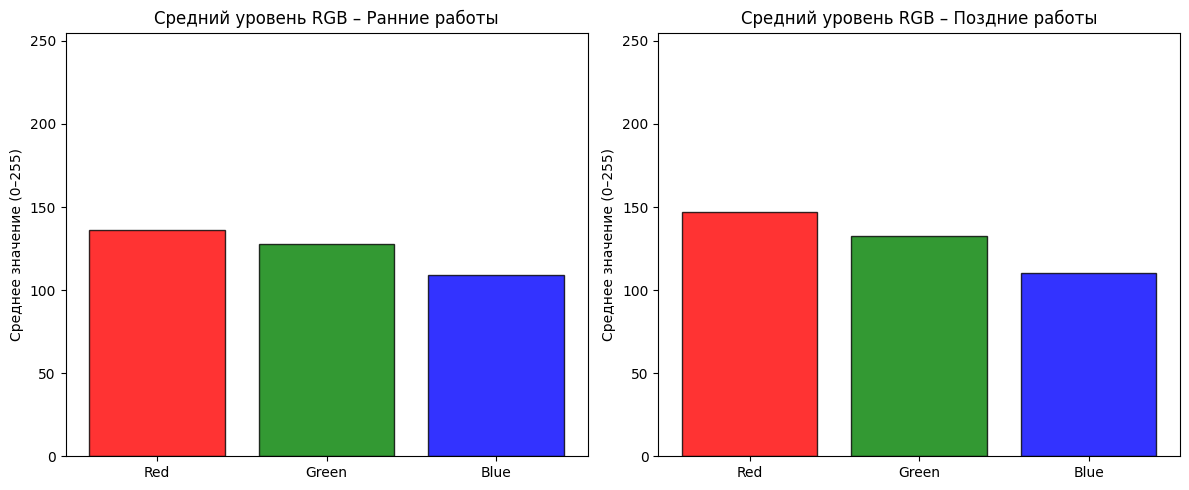

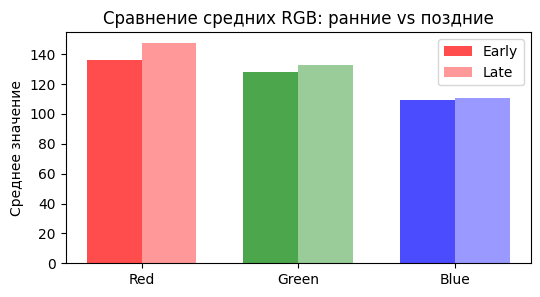

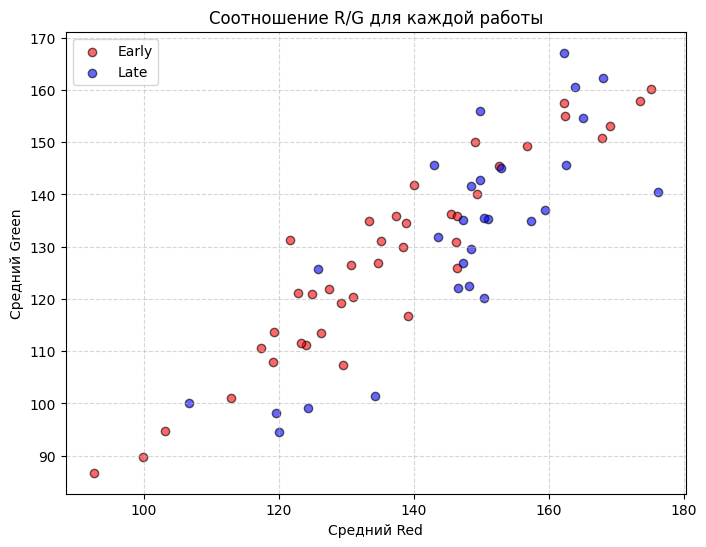

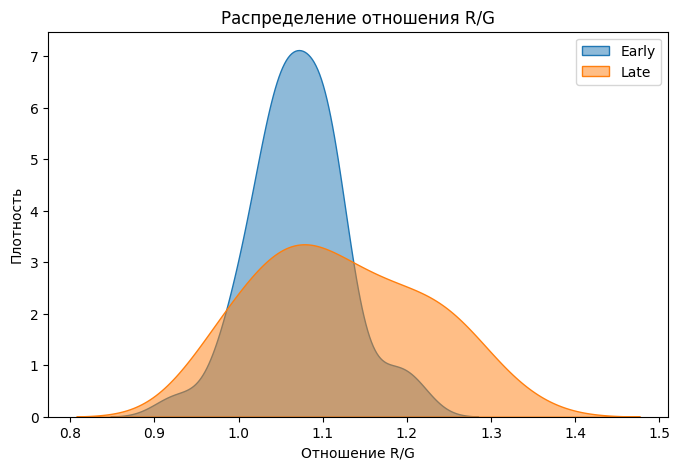

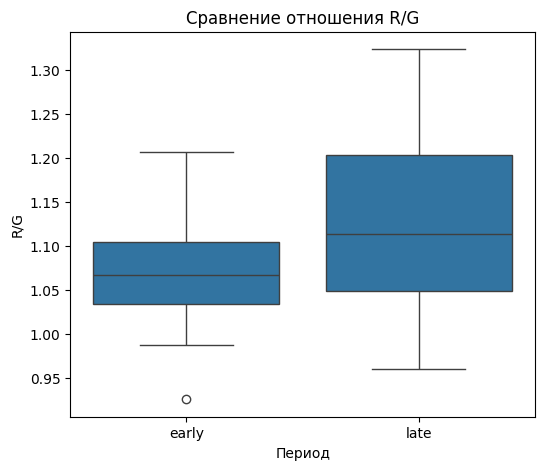

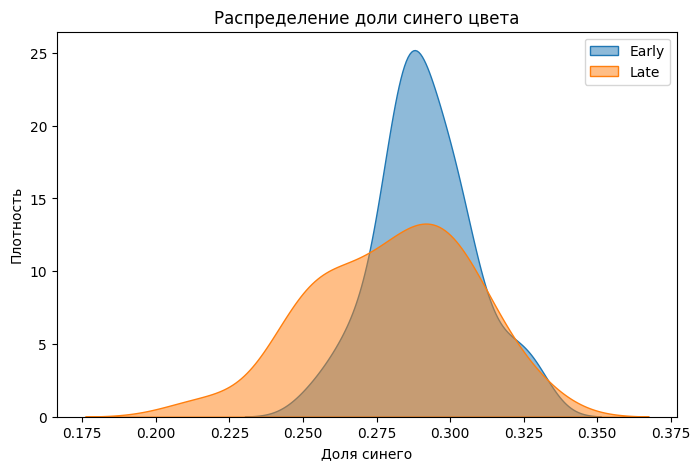

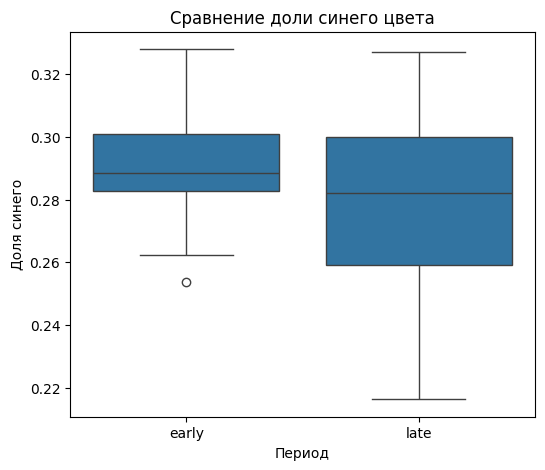


=== Отношение R/G ===
T = -2.463
p = 0.01837

=== Доля синего ===
T = 2.002
p = 0.05188


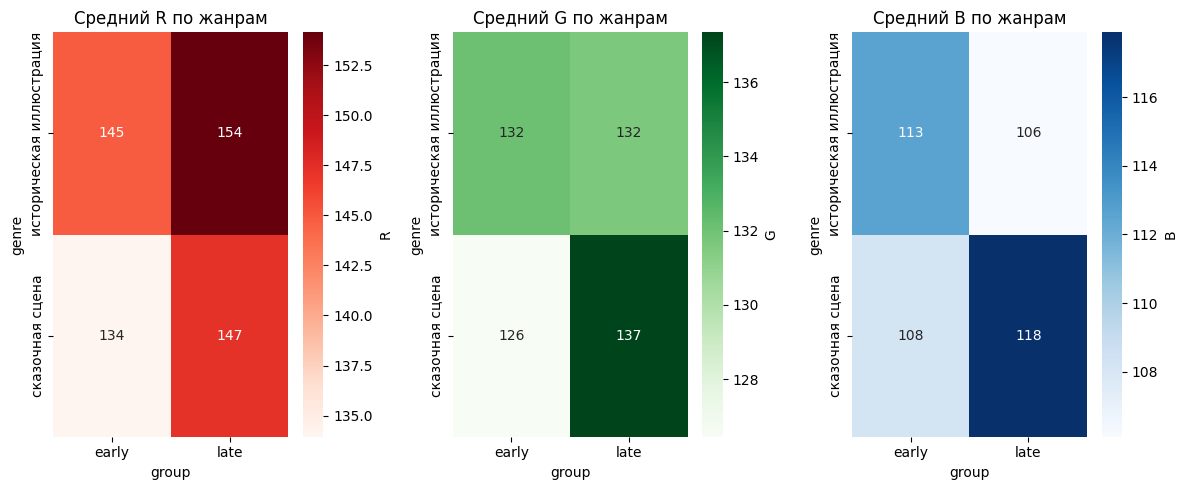

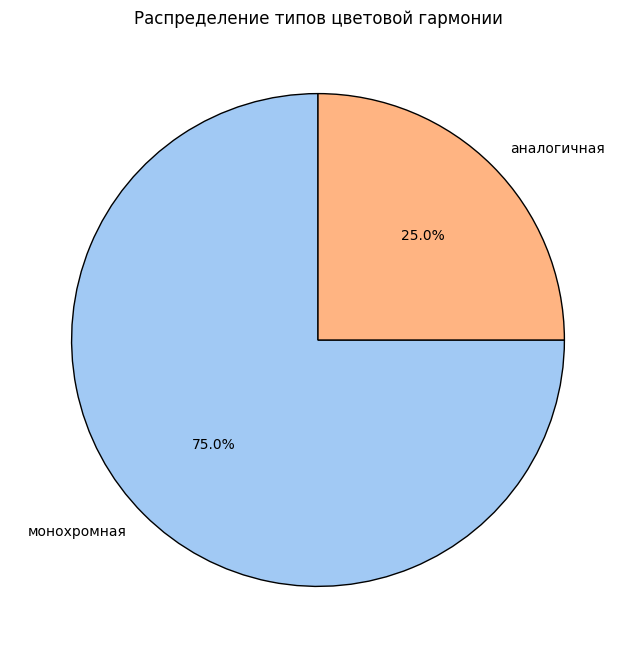

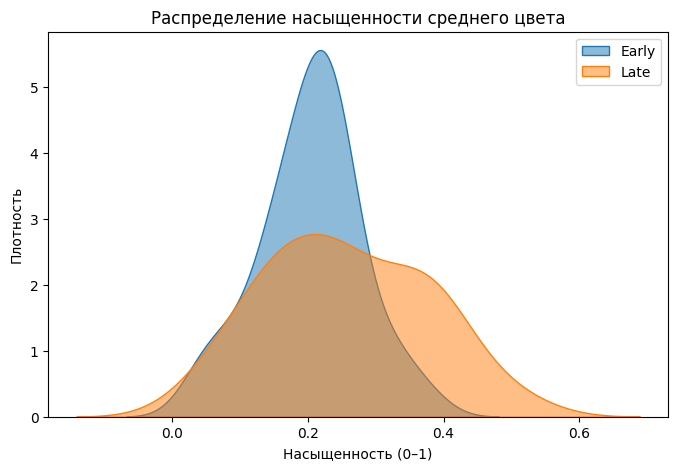


=== Сводная статистика ===
      r_g_ratio                     blue_share                     saturation  \
           mean       std    median       mean       std    median       mean   
group                                                                           
early  1.070559  0.054606  1.067204   0.291503  0.016295  0.288394   0.203550   
late   1.121572  0.099611  1.113270   0.280315  0.026246  0.282023   0.256788   

                          
           std    median  
group                     
early  0.07399  0.208623  
late   0.11870  0.257850  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from ast import literal_eval

# ==============================
# 1. Загрузка и подготовка данных
# ==============================
df = pd.read_csv('bilibin_analysis.csv')

# Преобразуем столбец palette из строки в список словарей
def parse_palette(pal_str):
    try:
        # Если строка похожа на JSON
        return json.loads(pal_str.replace("'", '"'))
    except:
        try:
            # Альтернативный парсинг через literal_eval
            return literal_eval(pal_str)
        except:
            return []

df['palette_parsed'] = df['palette'].apply(parse_palette)

# Функция для вычисления средневзвешенного RGB по палитре
def weighted_avg_rgb(palette):
    if not palette:
        return (np.nan, np.nan, np.nan)
    total_perc = sum(item['percentage'] for item in palette)
    if total_perc == 0:
        return (np.nan, np.nan, np.nan)
    r = sum(item['rgb'][0] * item['percentage'] for item in palette) / total_perc
    g = sum(item['rgb'][1] * item['percentage'] for item in palette) / total_perc
    b = sum(item['rgb'][2] * item['percentage'] for item in palette) / total_perc
    return (r, g, b)

df['avg_r'], df['avg_g'], df['avg_b'] = zip(*df['palette_parsed'].apply(weighted_avg_rgb))

# Удаляем строки с отсутствующими цветами
df_clean = df.dropna(subset=['avg_r', 'avg_g', 'avg_b'])

# Разделяем на ранние и поздние работы
early = df_clean[df_clean['group'] == 'early']
late = df_clean[df_clean['group'] == 'late']

# Вычисляем средние по группе
early_avg = [early['avg_r'].mean(), early['avg_g'].mean(), early['avg_b'].mean()]
late_avg = [late['avg_r'].mean(), late['avg_g'].mean(), late['avg_b'].mean()]

# ==============================
# 2. График 1 – средний RGB (ранние)
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['red', 'green', 'blue']
x = np.arange(3)

# Ранние работы
axes[0].bar(x, early_avg, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Red', 'Green', 'Blue'])
axes[0].set_ylabel('Среднее значение (0–255)')
axes[0].set_title('Средний уровень RGB – Ранние работы')
axes[0].set_ylim(0, 255)

# Поздние работы
axes[1].bar(x, late_avg, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Red', 'Green', 'Blue'])
axes[1].set_ylabel('Среднее значение (0–255)')
axes[1].set_title('Средний уровень RGB – Поздние работы')
axes[1].set_ylim(0, 255)

plt.tight_layout()
plt.show()

# ==============================
# 3. Дополнительный график – сравнение средних цветов двух периодов
# ==============================
# Визуализируем средние цвета как квадраты
fig, ax = plt.subplots(figsize=(6, 3))
bar_width = 0.35
x_pos = np.arange(3)

ax.bar(x_pos - bar_width/2, early_avg, width=bar_width, label='Early', color=['red', 'green', 'blue'], alpha=0.7)
ax.bar(x_pos + bar_width/2, late_avg, width=bar_width, label='Late', color=['red', 'green', 'blue'], alpha=0.4)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Red', 'Green', 'Blue'])
ax.set_ylabel('Среднее значение')
ax.set_title('Сравнение средних RGB: ранние vs поздние')
ax.legend()
plt.show()

# ==============================
# 4. Цветовое пространство – разброс средних цветов каждой работы
# ==============================
# Построим scatter plot для RGB-координат (например, G vs R)
plt.figure(figsize=(8, 6))
plt.scatter(early['avg_r'], early['avg_g'], c='red', label='Early', alpha=0.6, edgecolors='black')
plt.scatter(late['avg_r'], late['avg_g'], c='blue', label='Late', alpha=0.6, edgecolors='black')
plt.xlabel('Средний Red')
plt.ylabel('Средний Green')
plt.title('Соотношение R/G для каждой работы')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# 4.1. Анализ отношений цветовых каналов
# ==============================

# Отношение красного к зелёному
df_clean['r_g_ratio'] = df_clean['avg_r'] / df_clean['avg_g']

# Отношение красного к синему
df_clean['r_b_ratio'] = df_clean['avg_r'] / df_clean['avg_b']

# Доля синего в общем цвете
df_clean['blue_share'] = (
    df_clean['avg_b'] /
    (df_clean['avg_r'] + df_clean['avg_g'] + df_clean['avg_b'])
)

# ------------------------------
# KDE-график R/G
# ------------------------------

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_clean[df_clean['group']=='early'],
    x='r_g_ratio',
    fill=True,
    label='Early',
    alpha=0.5
)

sns.kdeplot(
    data=df_clean[df_clean['group']=='late'],
    x='r_g_ratio',
    fill=True,
    label='Late',
    alpha=0.5
)

plt.xlabel('Отношение R/G')
plt.ylabel('Плотность')
plt.title('Распределение отношения R/G')
plt.legend()
plt.show()

# ------------------------------
# Boxplot R/G
# ------------------------------

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_clean,
    x='group',
    y='r_g_ratio'
)

plt.xlabel('Период')
plt.ylabel('R/G')
plt.title('Сравнение отношения R/G')
plt.show()

# ------------------------------
# KDE-график доли синего
# ------------------------------

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_clean[df_clean['group']=='early'],
    x='blue_share',
    fill=True,
    label='Early',
    alpha=0.5
)

sns.kdeplot(
    data=df_clean[df_clean['group']=='late'],
    x='blue_share',
    fill=True,
    label='Late',
    alpha=0.5
)

plt.xlabel('Доля синего')
plt.ylabel('Плотность')
plt.title('Распределение доли синего цвета')
plt.legend()
plt.show()

# ------------------------------
# Boxplot доли синего
# ------------------------------

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_clean,
    x='group',
    y='blue_share'
)

plt.xlabel('Период')
plt.ylabel('Доля синего')
plt.title('Сравнение доли синего цвета')
plt.show()

# ------------------------------
# Статистическая проверка
# ------------------------------

from scipy.stats import ttest_ind

early_ratio = df_clean[df_clean['group']=='early']['r_g_ratio'].dropna()
late_ratio = df_clean[df_clean['group']=='late']['r_g_ratio'].dropna()

t_rg, p_rg = ttest_ind(
    early_ratio,
    late_ratio,
    equal_var=False
)

print('\n=== Отношение R/G ===')
print(f'T = {t_rg:.3f}')
print(f'p = {p_rg:.5f}')

early_blue = df_clean[df_clean['group']=='early']['blue_share'].dropna()
late_blue = df_clean[df_clean['group']=='late']['blue_share'].dropna()

t_blue, p_blue = ttest_ind(
    early_blue,
    late_blue,
    equal_var=False
)

print('\n=== Доля синего ===')
print(f'T = {t_blue:.3f}')
print(f'p = {p_blue:.5f}')




# ==============================
# 5. Тепловая карта средних палитр по жанрам и периодам
# ==============================
# Группируем по (group, genre) и вычисляем средний цвет
group_genre = df_clean.groupby(['group', 'genre'])[['avg_r', 'avg_g', 'avg_b']].mean().dropna()
# Создаём матрицу из трёх каналов для отображения
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for i, channel in enumerate(['avg_r', 'avg_g', 'avg_b']):
    pivot = group_genre[channel].unstack(level=0)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds' if channel=='avg_r' else 'Greens' if channel=='avg_g' else 'Blues',
                ax=axes[i], cbar_kws={'label': channel[-1].upper()})
    axes[i].set_title(f'Средний {channel[-1].upper()} по жанрам')
plt.tight_layout()
plt.show()

# ==============================
# 6. Круговая диаграмма – доля цветовой гармонии (color_harmony)
# ==============================
# Учитываем только non-null значения
harmony_counts = df_clean['color_harmony'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(harmony_counts, labels=harmony_counts.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
plt.title('Распределение типов цветовой гармонии')
plt.show()

# ==============================
# 7. Анализ насыщенности (вычисляем как max(R,G,B)-min(R,G,B) / 255)
# ==============================
def saturation(row):
    rgb = np.array([row['avg_r'], row['avg_g'], row['avg_b']])
    if np.any(np.isnan(rgb)):
        return np.nan
    max_val = rgb.max()
    min_val = rgb.min()
    if max_val == 0:
        return 0
    return (max_val - min_val) / max_val

df_clean['saturation'] = df_clean.apply(saturation, axis=1)
early_sat = df_clean[df_clean['group']=='early']['saturation'].dropna()
late_sat = df_clean[df_clean['group']=='late']['saturation'].dropna()

plt.figure(figsize=(8, 5))
sns.kdeplot(early_sat, label='Early', fill=True, alpha=0.5)
sns.kdeplot(late_sat, label='Late', fill=True, alpha=0.5)
plt.xlabel('Насыщенность (0–1)')
plt.ylabel('Плотность')
plt.title('Распределение насыщенности среднего цвета')
plt.legend()
plt.show()

# ------------------------------
# Сводная таблица
# ------------------------------

summary = df_clean.groupby('group').agg({
    'r_g_ratio': ['mean', 'std', 'median'],
    'blue_share': ['mean', 'std', 'median'],
    'saturation': ['mean', 'std', 'median']
})

print('\n=== Сводная статистика ===')
print(summary)

=== ТОП-5 ОТТЕНКОВ (ранний период) ===
hex_approx  percent  r_round  g_round  b_round
   #646450    231.7      100      100       80
   #8c7864    229.8      140      120      100
   #786450    181.1      120      100       80
   #787864    177.9      120      120      100
   #50503c    160.2       80       80       60

=== ТОП-5 ОТТЕНКОВ (поздний период) ===
hex_approx  percent  r_round  g_round  b_round
   #b4a078    231.1      180      160      120
   #64503c    174.7      100       80       60
   #282814    166.4       40       40       20
   #c8a078    106.7      200      160      120
   #a07850    102.0      160      120       80


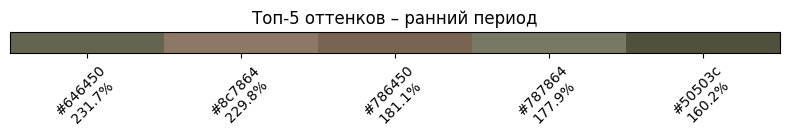

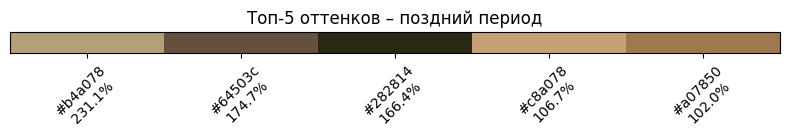

In [15]:
import pandas as pd
import json
from ast import literal_eval

# 1. Загрузка данных
df = pd.read_csv('bilibin_analysis.csv')

# 2. Функция парсинга палитры (как и раньше)
def parse_palette(pal_str):
    try:
        return json.loads(pal_str.replace("'", '"'))
    except:
        try:
            return literal_eval(pal_str)
        except:
            return []

df['palette_parsed'] = df['palette'].apply(parse_palette)

# 3. Разворачиваем каждый цвет из каждой работы в отдельную строку
rows = []
for idx, row in df.iterrows():
    group = row['group']
    for color in row['palette_parsed']:
        hex_code = color['hex']
        rgb = color['rgb']
        percent = color['percentage']
        rows.append({
            'group': group,
            'hex': hex_code,
            'r': rgb[0],
            'g': rgb[1],
            'b': rgb[2],
            'percent': percent
        })
colors_df = pd.DataFrame(rows)

# 4. Обобщение цветов: округление RGB до ближайшего кратного 30
#    (чем больше шаг, тем сильнее обобщение; 15–30 оптимально)
def generalize_rgb(r, g, b, step=20):
    return (round(r / step) * step,
            round(g / step) * step,
            round(b / step) * step)

colors_df['r_round'], colors_df['g_round'], colors_df['b_round'] = zip(
    *colors_df.apply(lambda x: generalize_rgb(x['r'], x['g'], x['b'], step=20), axis=1)
)

# 5. Суммируем проценты для каждой обобщённой группы цветов внутри периода
grouped = colors_df.groupby(['group', 'r_round', 'g_round', 'b_round'])['percent'].sum().reset_index()
# Добавим колонку hex для визуализации (приблизительный)
grouped['hex_approx'] = grouped.apply(lambda x: f"#{x['r_round']:02x}{x['g_round']:02x}{x['b_round']:02x}", axis=1)

# 6. Для каждого периода берём топ-5 по суммарному проценту
top_early = grouped[grouped['group']=='early'].nlargest(5, 'percent')[['hex_approx', 'percent', 'r_round', 'g_round', 'b_round']]
top_late = grouped[grouped['group']=='late'].nlargest(5, 'percent')[['hex_approx', 'percent', 'r_round', 'g_round', 'b_round']]

print("=== ТОП-5 ОТТЕНКОВ (ранний период) ===")
print(top_early.to_string(index=False))
print("\n=== ТОП-5 ОТТЕНКОВ (поздний период) ===")
print(top_late.to_string(index=False))

def hex_to_rgb(hex_color):
    """Преобразует hex вида '#RRGGBB' в кортеж (R, G, B) от 0 до 255"""
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

def plot_top_colors(top_df, title):
    fig, ax = plt.subplots(figsize=(8, 1.5))
    hex_colors = top_df['hex_approx'].values
    # Переводим hex в RGB и нормализуем в [0, 1] для matplotlib
    rgb_colors = np.array([hex_to_rgb(c) for c in hex_colors]) / 255.0
    # Формируем массив размером (1, количество_цветов, 3)
    rgb_colors = rgb_colors.reshape(1, -1, 3)
    ax.imshow(rgb_colors, aspect='auto')
    ax.set_xticks(range(len(hex_colors)))
    ax.set_xticklabels([f"{c}\n{p:.1f}%" for c, p in zip(hex_colors, top_df['percent'])], rotation=45)
    ax.set_yticks([])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Вызов исправленной функции
plot_top_colors(top_early, "Топ-5 оттенков – ранний период")
plot_top_colors(top_late, "Топ-5 оттенков – поздний период")

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def hex_to_rgb(hex_color):
    """Преобразует hex вида '#RRGGBB' в кортеж (R, G, B) от 0 до 255"""
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

def plot_top_colors(top_df, title):
    fig, ax = plt.subplots(figsize=(8, 1.5))
    hex_colors = top_df['hex_approx'].values
    # Переводим hex в RGB и нормализуем в [0, 1] для matplotlib
    rgb_colors = np.array([hex_to_rgb(c) for c in hex_colors]) / 255.0
    # Формируем массив размером (1, количество_цветов, 3)
    rgb_colors = rgb_colors.reshape(1, -1, 3)
    ax.imshow(rgb_colors, aspect='auto')
    ax.set_xticks(range(len(hex_colors)))
    ax.set_xticklabels([f"{c}\n{p:.1f}%" for c, p in zip(hex_colors, top_df['percent'])], rotation=45)
    ax.set_yticks([])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Вызов исправленной функции
plot_top_colors(top_early, "Топ-5 оттенков – ранний период")
plot_top_colors(top_late, "Топ-5 оттенков – поздний период")

Размер выборки: ранние = 40, поздние = 28



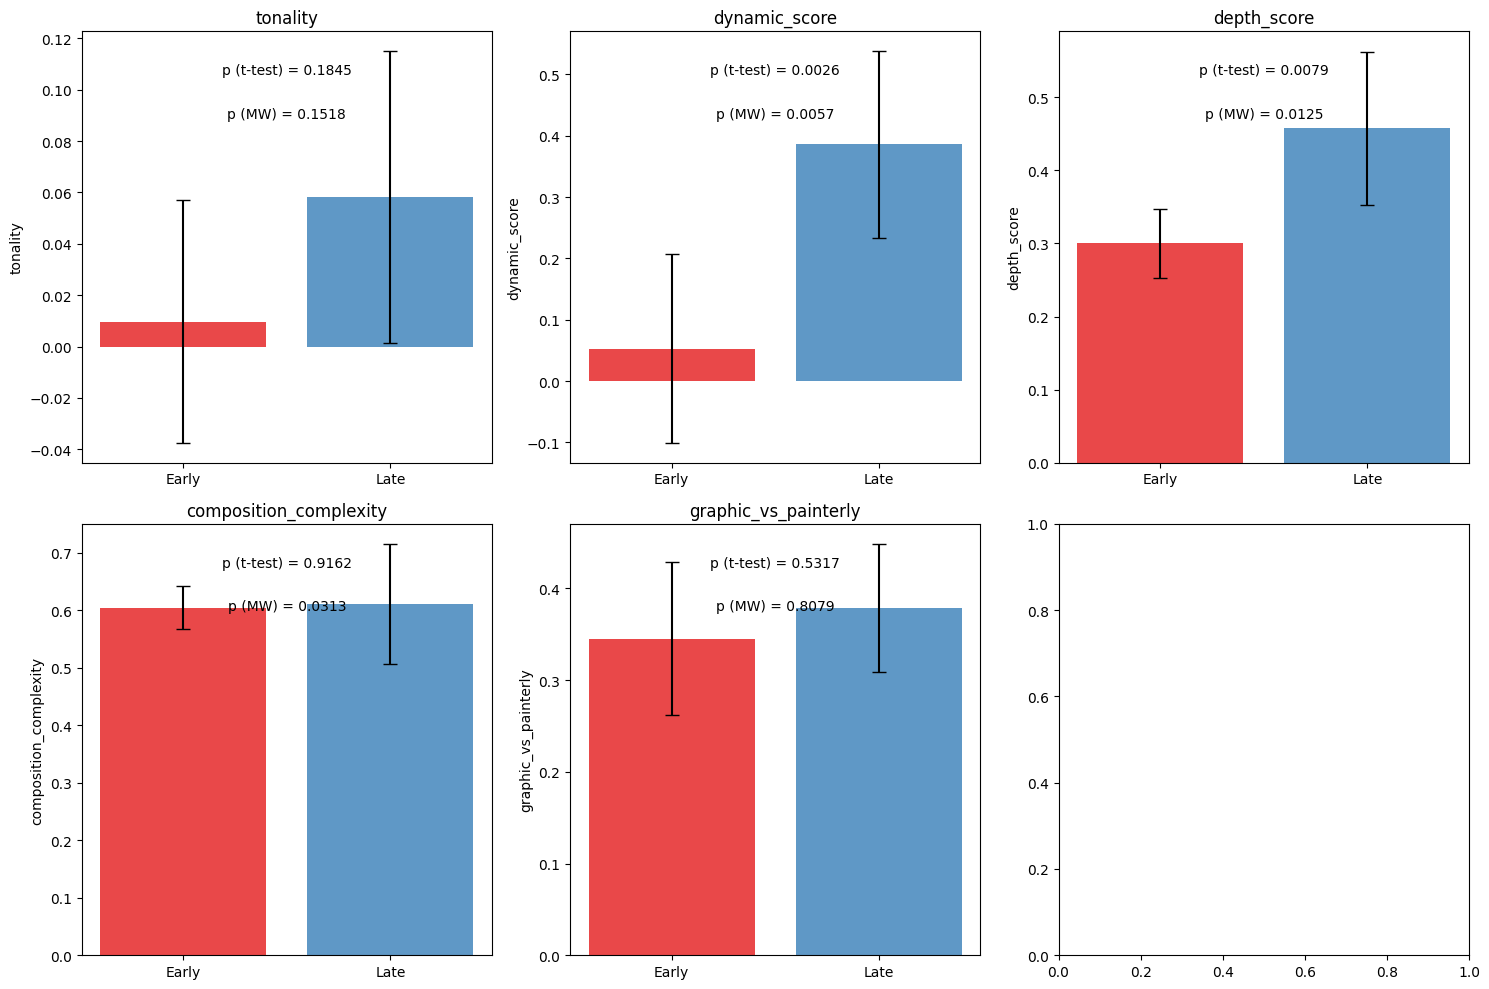

Сводная таблица сравнения средних:
              variable  t-test p-value  Mann-Whitney p-value  early_mean  late_mean     diff
              tonality        0.184542              0.151846    0.009675   0.058321 0.048646
         dynamic_score        0.002596              0.005750    0.052500   0.385714 0.333214
           depth_score        0.007906              0.012546    0.300000   0.457143 0.157143
composition_complexity        0.916229              0.031331    0.605000   0.610714 0.005714
  graphic_vs_painterly        0.531726              0.807861    0.345000   0.378571 0.033571


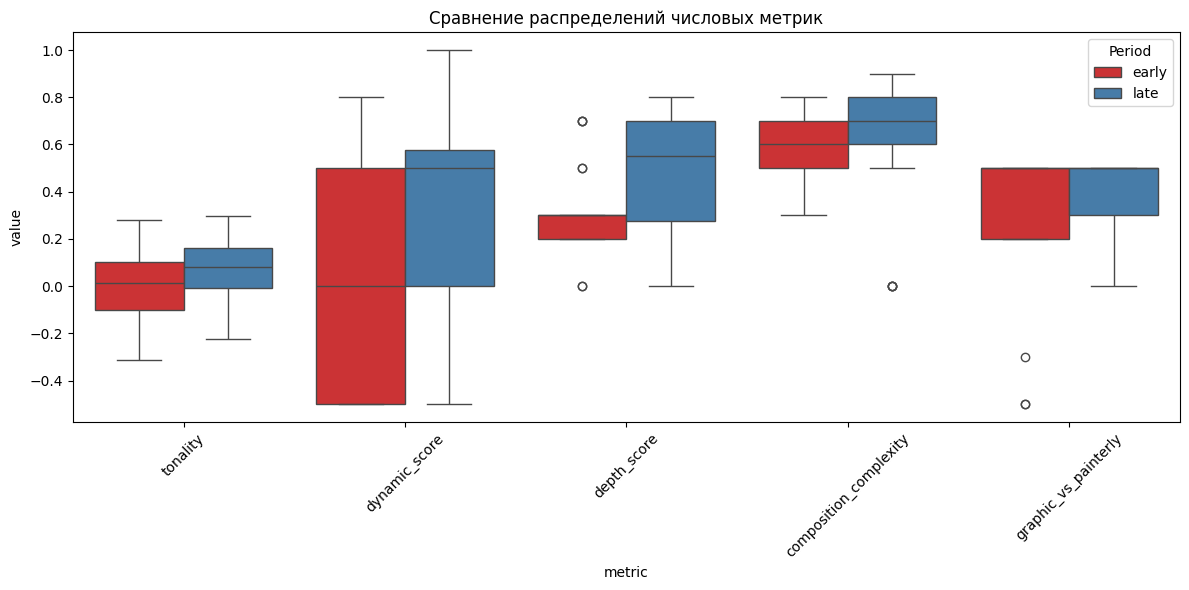


=== Статистическая значимость (α=0.05) ===

tonality:
  Среднее early = 0.010, late = 0.058, разница = 0.049
  t-test: p = 0.1845 -> значимых различий нет
  Mann-Whitney: p = 0.1518 -> значимых различий нет

dynamic_score:
  Среднее early = 0.052, late = 0.386, разница = 0.333
  t-test: p = 0.0026 -> различие статистически значимо
  Mann-Whitney: p = 0.0057 -> различие значимо

depth_score:
  Среднее early = 0.300, late = 0.457, разница = 0.157
  t-test: p = 0.0079 -> различие статистически значимо
  Mann-Whitney: p = 0.0125 -> различие значимо

composition_complexity:
  Среднее early = 0.605, late = 0.611, разница = 0.006
  t-test: p = 0.9162 -> значимых различий нет
  Mann-Whitney: p = 0.0313 -> различие значимо

graphic_vs_painterly:
  Среднее early = 0.345, late = 0.379, разница = 0.034
  t-test: p = 0.5317 -> значимых различий нет
  Mann-Whitney: p = 0.8079 -> значимых различий нет


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================
# 1. Загрузка и предобработка
# ==============================
df = pd.read_csv('bilibin_analysis.csv', encoding='utf-8-sig')

# Удаляем строки, где в поздних работах отсутствуют данные (numerical columns)
numeric_cols = ['tonality', 'dynamic_score', 'depth_score',
                'composition_complexity', 'graphic_vs_painterly']
df_clean = df.dropna(subset=numeric_cols)

# Убедимся, что все числовые колонки имеют тип float
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Разделяем на группы
early = df_clean[df_clean['group'] == 'early']
late = df_clean[df_clean['group'] == 'late']

print("Размер выборки: ранние = {}, поздние = {}".format(len(early), len(late)))
print()

# ==============================
# 2. Вспомогательные функции
# ==============================
def mean_confidence_interval(data, confidence=0.95):
    """Возвращает полуширину доверительного интервала (upper - mean)"""
    a = 1.0 * np.array(data)
    n = len(a)
    if n < 2:
        return 0
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return h

def plot_comparison(df_early, df_late, col_name, ax):
    """Строит barplot со средними и 95% ДИ для одной переменной"""
    means = [df_early[col_name].mean(), df_late[col_name].mean()]
    errors = [mean_confidence_interval(df_early[col_name]),
              mean_confidence_interval(df_late[col_name])]

    x = [0, 1]
    ax.bar(x, means, yerr=errors, capsize=5, color=['#e41a1c', '#377eb8'], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['Early', 'Late'])
    ax.set_ylabel(col_name)
    ax.set_title(col_name)

def significance_tests(df_early, df_late, col_name):
    """Проводит t-test и Mann-Whitney U test, возвращает p-значения"""
    early_vals = df_early[col_name].dropna()
    late_vals = df_late[col_name].dropna()

    # t-test (Welch, unequal variance)
    t_stat, t_p = stats.ttest_ind(early_vals, late_vals, equal_var=False)
    # Mann-Whitney U test (non-parametric)
    u_stat, u_p = stats.mannwhitneyu(early_vals, late_vals, alternative='two-sided')

    return t_p, u_p

# ==============================
# 3. Построение графиков и тесты
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

results = []
for i, col in enumerate(numeric_cols):
    plot_comparison(early, late, col, axes[i])
    t_p, u_p = significance_tests(early, late, col)
    results.append({
        'variable': col,
        't-test p-value': t_p,
        'Mann-Whitney p-value': u_p,
        'early_mean': early[col].mean(),
        'late_mean': late[col].mean(),
        'diff': late[col].mean() - early[col].mean()
    })
    # Добавим текстовую аннотацию с p-value
    axes[i].text(0.5, 0.9, f"p (t-test) = {t_p:.4f}", transform=axes[i].transAxes, ha='center')
    axes[i].text(0.5, 0.8, f"p (MW) = {u_p:.4f}", transform=axes[i].transAxes, ha='center')

plt.tight_layout()
plt.show()

# ==============================
# 4. Таблица результатов
# ==============================
results_df = pd.DataFrame(results)
print("Сводная таблица сравнения средних:")
print(results_df.to_string(index=False))

# ==============================
# 5. Дополнительно: boxplots для всех переменных на одном графике
# ==============================
df_melted = df_clean.melt(id_vars=['group'], value_vars=numeric_cols,
                          var_name='metric', value_name='value')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='metric', y='value', hue='group', palette={'early':'#e41a1c', 'late':'#377eb8'})
plt.title('Сравнение распределений числовых метрик')
plt.xticks(rotation=45)
plt.legend(title='Period')
plt.tight_layout()
plt.show()

# ==============================
# 6. Интерпретация значимости (α = 0.05)
# ==============================
print("\n=== Статистическая значимость (α=0.05) ===")
for res in results:
    var = res['variable']
    print(f"\n{var}:")
    print(f"  Среднее early = {res['early_mean']:.3f}, late = {res['late_mean']:.3f}, разница = {res['diff']:.3f}")
    if res['t-test p-value'] < 0.05:
        print(f"  t-test: p = {res['t-test p-value']:.4f} -> различие статистически значимо")
    else:
        print(f"  t-test: p = {res['t-test p-value']:.4f} -> значимых различий нет")
    if res['Mann-Whitney p-value'] < 0.05:
        print(f"  Mann-Whitney: p = {res['Mann-Whitney p-value']:.4f} -> различие значимо")
    else:
        print(f"  Mann-Whitney: p = {res['Mann-Whitney p-value']:.4f} -> значимых различий нет")

Всего строк: 68 (ранних: 40, поздних: 28)



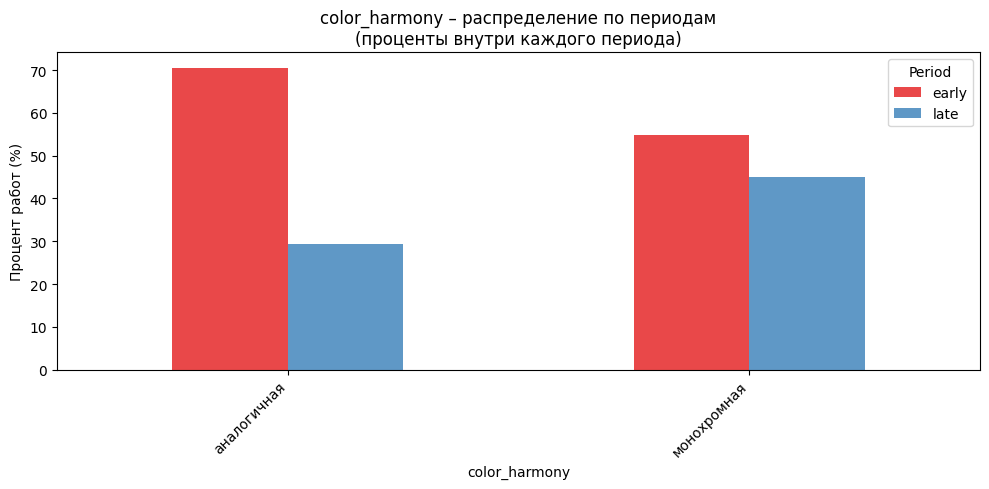


color_harmony:
color_harmony  аналогичная  монохромная
group                                  
early                   12           28
late                     5           23
Минимальная ожидаемая частота = 7.00
Хи-квадрат: p = 0.39335
Различия статистически не значимы
--------------------------------------------------


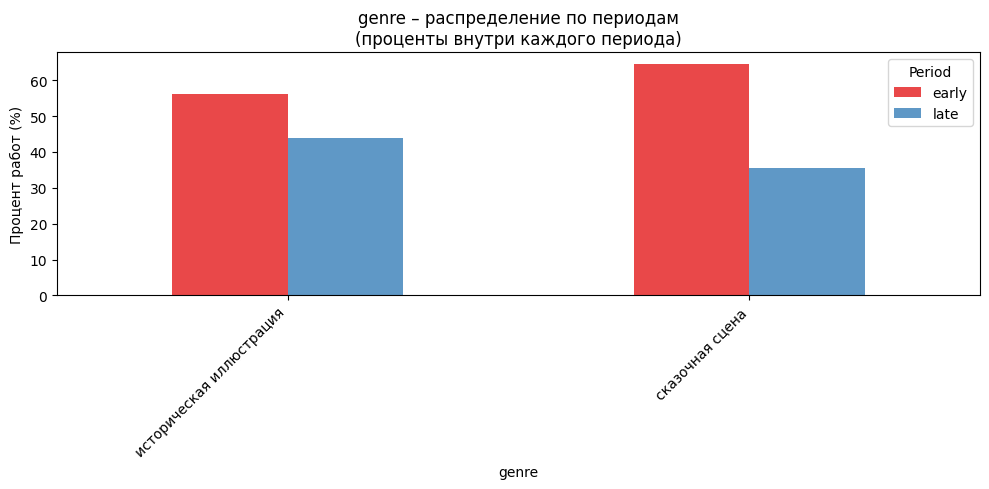


genre:
genre  историческая иллюстрация  сказочная сцена
group                                           
early                         9               31
late                          7               17
Минимальная ожидаемая частота = 6.00
Хи-квадрат: p = 0.76559
Различия статистически не значимы
--------------------------------------------------


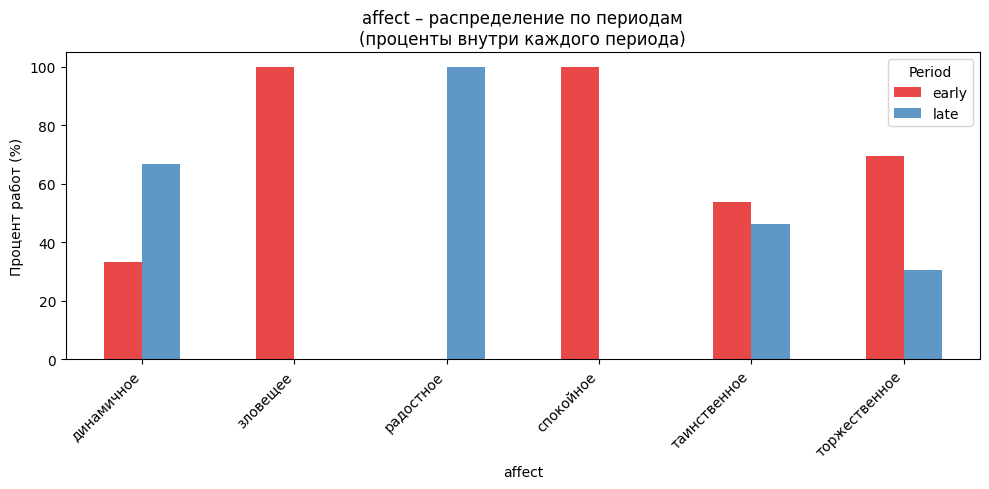


affect:
affect  динамичное  зловещее  радостное  спокойное  таинственное  \
group                                                              
early            2         1          0          7            14   
late             4         0          1          0            12   

affect  торжественное  
group                  
early              16  
late                7  
Минимальная ожидаемая частота = 0.38
Хи-квадрат: p = 0.07623
Различия статистически не значимы
--------------------------------------------------


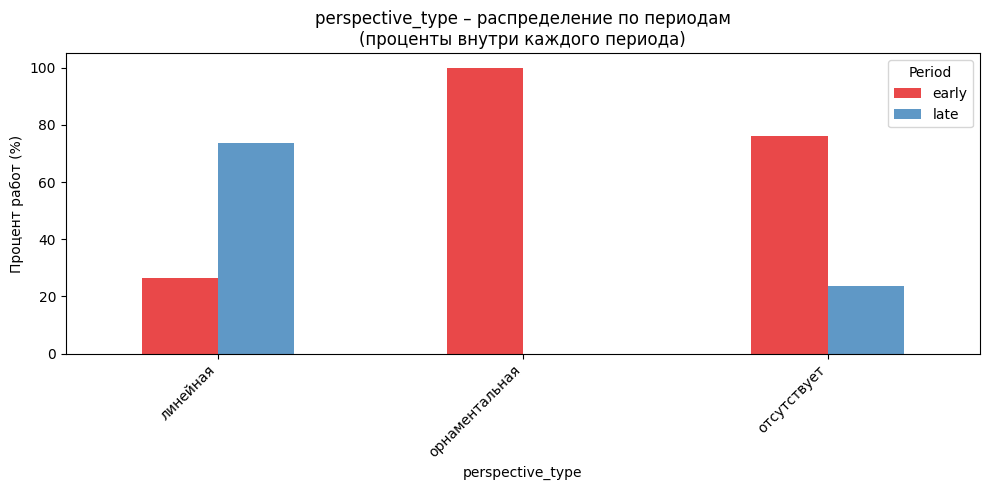


perspective_type:
perspective_type  линейная  орнаментальная  отсутствует
group                                                  
early                    5               3           32
late                    14               0           10
Минимальная ожидаемая частота = 1.12
Хи-квадрат: p = 0.00038
Cramér's V = 0.467 (связь средняя)
--------------------------------------------------


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact

# ------------------------------
# 1. Загрузка данных
# ------------------------------
df = pd.read_csv('bilibin_analysis.csv', encoding='utf-8-sig')
categorical_cols = ['color_harmony', 'genre', 'affect', 'perspective_type']

# Заменяем пустые строки на NaN (но не удаляем строки)
for col in categorical_cols:
    df[col] = df[col].replace('', np.nan)

print(f"Всего строк: {len(df)} (ранних: {len(df[df['group']=='early'])}, поздних: {len(df[df['group']=='late'])})\n")

# ------------------------------
# 2. Функция для анализа одной категории
# ------------------------------
def cramers_v(conf_matrix):
    """Cramér's V для таблицы сопряжённости"""
    chi2 = chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = conf_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def analyze_categorical(col_name):
    # Убираем только те строки, где в этом столбце NaN
    data = df.dropna(subset=[col_name])
    if len(data) == 0:
        print(f"{col_name}: нет данных")
        return

    # Таблица сопряжённости: group vs категория
    cross = pd.crosstab(data['group'], data[col_name])
    # Проценты по столбцам (чтобы сумма по периодам = 100%)
    cross_percent = cross.div(cross.sum(axis=0), axis=1) * 100

    # График
    ax = cross_percent.T.plot(kind='bar', figsize=(10, 5),
                              color=['#e41a1c', '#377eb8'], alpha=0.8)
    ax.set_title(f'{col_name} – распределение по периодам\n(проценты внутри каждого периода)')
    ax.set_ylabel('Процент работ (%)')
    ax.set_xlabel(col_name)
    ax.legend(title='Period')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Статистический тест
    if cross.shape[1] < 2:
        print(f"{col_name}: только одна категория, тест невозможен\n")
        return

    chi2, p, dof, expected = chi2_contingency(cross)
    min_exp = expected.min()
    print(f"\n{col_name}:")
    print(cross)
    print(f"Минимальная ожидаемая частота = {min_exp:.2f}")

    # Если таблица 2x2 и min_exp < 5, используем точный тест Фишера
    if cross.shape == (2, 2) and min_exp < 5:
        _, p = fisher_exact(cross)
        print(f"Точный тест Фишера: p = {p:.5f}")
    else:
        print(f"Хи-квадрат: p = {p:.5f}")

    if p < 0.05:
        v = cramers_v(cross.values)
        print(f"Cramér's V = {v:.3f} (связь {'сильная' if v > 0.5 else 'средняя' if v > 0.3 else 'слабая'})")
    else:
        print("Различия статистически не значимы")
    print("-" * 50)

# ------------------------------
# 3. Запуск анализа для всех категорий
# ------------------------------
for col in categorical_cols:
    analyze_categorical(col)

Ранние работы: 40, Поздние работы: 24



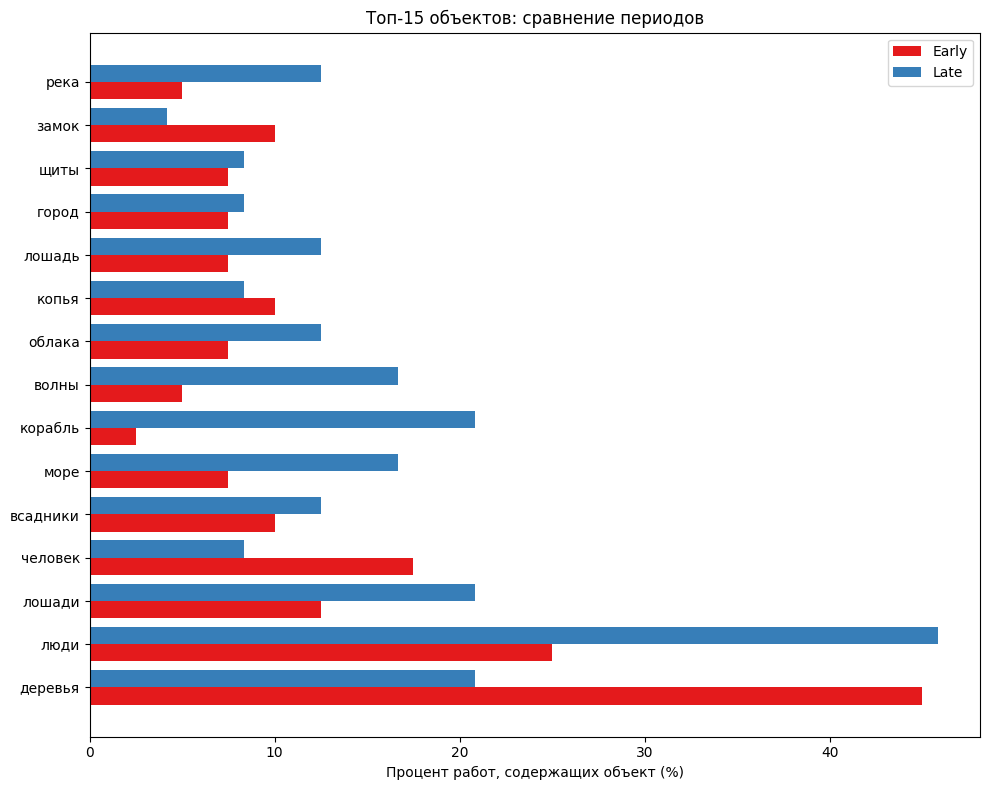


Статистическая значимость различий (Fisher's exact test):
  object  early_count  late_count  early_%    late_%  p_value  significant
 деревья           18           5     45.0 20.833333 0.063386        False
    люди           10          11     25.0 45.833333 0.104636        False
  лошади            5           5     12.5 20.833333 0.481617        False
 человек            7           2     17.5  8.333333 0.464032        False
всадники            4           3     10.0 12.500000 1.000000        False
    море            3           4      7.5 16.666667 0.409894        False
 корабль            1           5      2.5 20.833333 0.024472         True
   волны            2           4      5.0 16.666667 0.186216        False
  облака            3           3      7.5 12.500000 0.663570        False
   копья            4           2     10.0  8.333333 1.000000        False
  лошадь            3           3      7.5 12.500000 0.663570        False
   город            3           2      7.

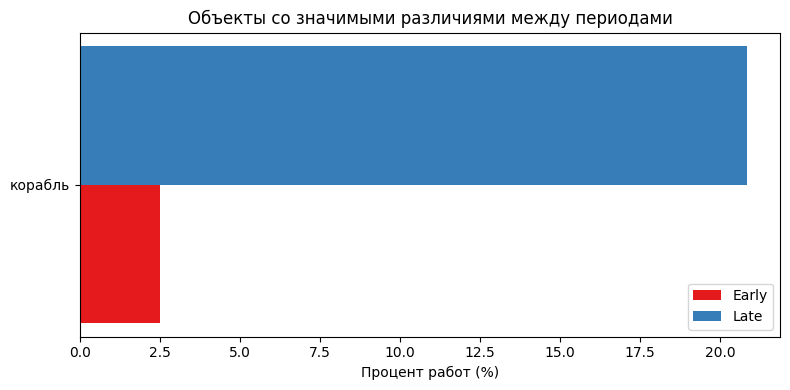

In [19]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import fisher_exact, chi2_contingency

# ------------------------------
# 1. Загрузка данных и парсинг objects
# ------------------------------
df = pd.read_csv('bilibin_analysis.csv', encoding='utf-8-sig')

def parse_objects(obj_str):
    try:
        # Замена возможных кавычек и использование ast.literal_eval
        return ast.literal_eval(obj_str)
    except:
        # Если не получилось, пробуем заменить двойные кавычки
        try:
            return ast.literal_eval(obj_str.replace('""', '"'))
        except:
            return []

df['objects_parsed'] = df['objects'].apply(parse_objects)

# Удаляем строки, где список объектов пуст
df = df[df['objects_parsed'].apply(len) > 0].copy()

# ------------------------------
# 2. Подсчёт частот объектов по периодам
# ------------------------------
def count_objects_by_period(df, period):
    """Возвращает Counter с объектами для заданного периода (early/late)"""
    objects_list = df[df['group'] == period]['objects_parsed'].sum()
    return Counter(objects_list)

early_counts = count_objects_by_period(df, 'early')
late_counts = count_objects_by_period(df, 'late')

# Общее количество работ в каждом периоде
n_early = len(df[df['group'] == 'early'])
n_late = len(df[df['group'] == 'late'])

print(f"Ранние работы: {n_early}, Поздние работы: {n_late}\n")

# ------------------------------
# 3. Топ-15 объектов (по суммарной частоте)
# ------------------------------
all_objects = set(early_counts.keys()) | set(late_counts.keys())
# Суммарная частота для сортировки
total_counts = Counter()
total_counts.update(early_counts)
total_counts.update(late_counts)
top_objects = [obj for obj, _ in total_counts.most_common(15)]

# Подготовка данных для графика
data = []
for obj in top_objects:
    early_freq = early_counts.get(obj, 0) / n_early * 100  # процент работ с этим объектом
    late_freq = late_counts.get(obj, 0) / n_late * 100
    data.append([obj, early_freq, late_freq])

df_plot = pd.DataFrame(data, columns=['object', 'early_%', 'late_%'])

# Горизонтальная столбчатая диаграмма
fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top_objects))
ax.barh(y_pos - 0.2, df_plot['early_%'], height=0.4, label='Early', color='#e41a1c')
ax.barh(y_pos + 0.2, df_plot['late_%'], height=0.4, label='Late', color='#377eb8')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['object'])
ax.set_xlabel('Процент работ, содержащих объект (%)')
ax.set_title('Топ-15 объектов: сравнение периодов')
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------
# 4. Статистическая значимость для каждого объекта
# ------------------------------
def test_object_significance(obj):
    """Возвращает p-value для различия частот объекта между периодами (тест Фишера)"""
    a = early_counts.get(obj, 0)          # есть в ранних
    b = n_early - a                        # нет в ранних
    c = late_counts.get(obj, 0)            # есть в поздних
    d = n_late - c                         # нет в поздних
    table = [[a, b], [c, d]]
    oddsr, p = fisher_exact(table, alternative='two-sided')
    return p

# Собираем результаты для топ-15
results = []
for obj in top_objects:
    p_val = test_object_significance(obj)
    results.append({
        'object': obj,
        'early_count': early_counts.get(obj, 0),
        'late_count': late_counts.get(obj, 0),
        'early_%': early_counts.get(obj, 0) / n_early * 100,
        'late_%': late_counts.get(obj, 0) / n_late * 100,
        'p_value': p_val,
        'significant': p_val < 0.05
    })

df_results = pd.DataFrame(results)
print("\nСтатистическая значимость различий (Fisher's exact test):")
print(df_results.to_string(index=False))

# Отфильтруем объекты с p < 0.05
sig_objects = df_results[df_results['significant']]
print("\nОбъекты со статистически значимыми различиями:")
print(sig_objects[['object', 'early_%', 'late_%', 'p_value']].to_string(index=False))

# ------------------------------
# 5. Дополнительно: разнообразие объектов (индекс Шеннона или количество уникальных объектов)
# ------------------------------
early_unique = len(early_counts)
late_unique = len(late_counts)
print(f"\nУникальных объектов: ранние = {early_unique}, поздние = {late_unique}")

# Нормализованное разнообразие на работу
early_avg_objects = sum(len(lst) for lst in df[df['group']=='early']['objects_parsed']) / n_early
late_avg_objects = sum(len(lst) for lst in df[df['group']=='late']['objects_parsed']) / n_late
print(f"Среднее количество объектов на работу: ранние = {early_avg_objects:.2f}, поздние = {late_avg_objects:.2f}")

# ------------------------------
# 6. Визуализация частоты для значимых объектов (как "бабочка")
# ------------------------------
if len(sig_objects) > 0:
    fig, ax = plt.subplots(figsize=(8, max(4, len(sig_objects)*0.5)))
    y_pos = np.arange(len(sig_objects))
    ax.barh(y_pos - 0.2, sig_objects['early_%'], height=0.4, label='Early', color='#e41a1c')
    ax.barh(y_pos + 0.2, sig_objects['late_%'], height=0.4, label='Late', color='#377eb8')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sig_objects['object'])
    ax.set_xlabel('Процент работ (%)')
    ax.set_title('Объекты со значимыми различиями между периодами')
    ax.legend()
    plt.tight_layout()
    plt.show()

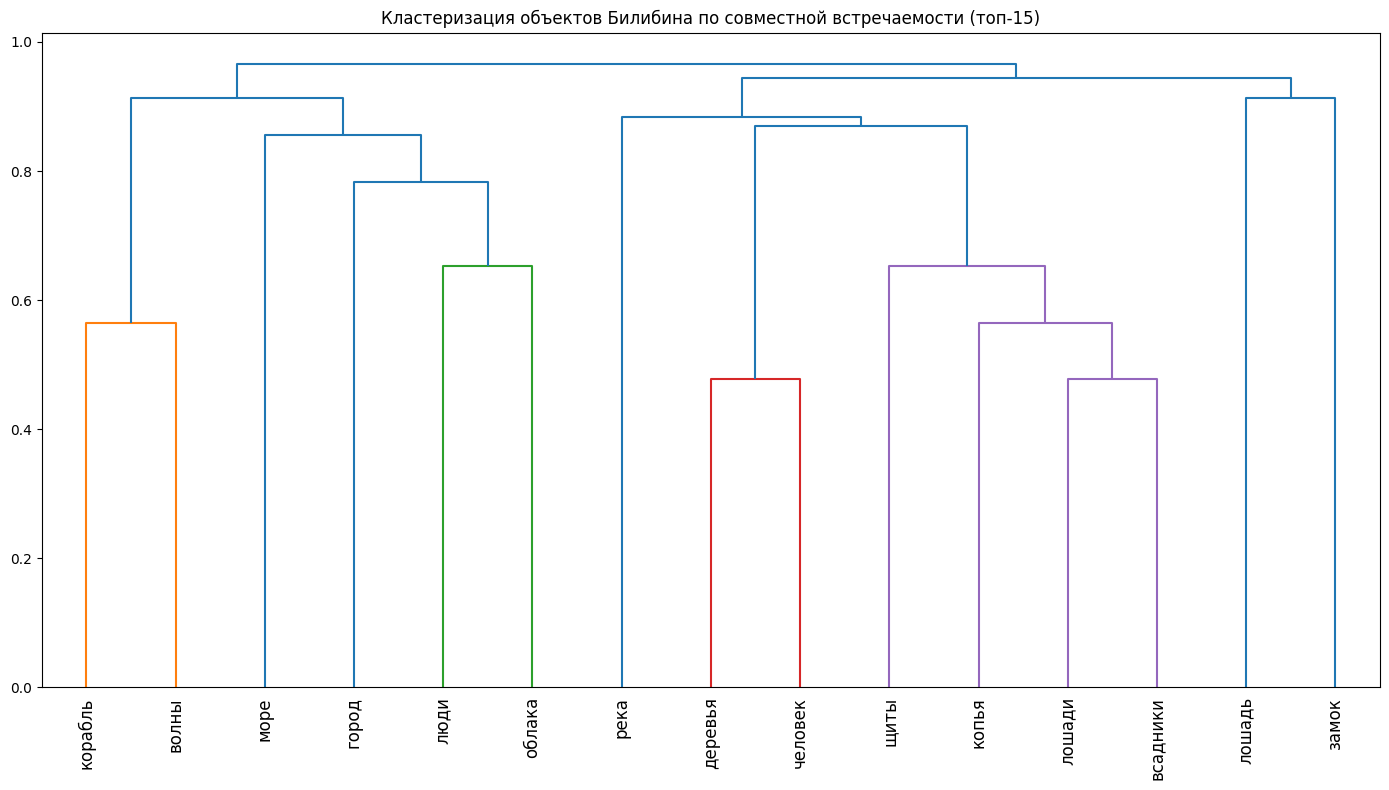


Кластеры объектов:
Кластер 1: ['люди', 'море', 'корабль', 'волны', 'облака', 'город']
Кластер 2: ['деревья', 'лошади', 'человек', 'всадники', 'копья', 'лошадь', 'щиты', 'замок', 'река']


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import ast
from collections import Counter

# ------------------------------
# 1. Загрузка и парсинг (если ещё не сделано)
# ------------------------------
df = pd.read_csv('bilibin_analysis.csv', encoding='utf-8-sig')
def parse_objects(obj_str):
    try:
        return ast.literal_eval(obj_str)
    except:
        try:
            return ast.literal_eval(obj_str.replace('""', '"'))
        except:
            return []
df['objects_parsed'] = df['objects'].apply(parse_objects)
df = df[df['objects_parsed'].apply(len) > 0].copy()

n_early = len(df[df['group']=='early'])
n_late = len(df[df['group']=='late'])

# Собираем все объекты и их общую частоту
early_counts = Counter()
late_counts = Counter()
for _, row in df.iterrows():
    if row['group'] == 'early':
        early_counts.update(row['objects_parsed'])
    else:
        late_counts.update(row['objects_parsed'])

total_counts = Counter()
total_counts.update(early_counts)
total_counts.update(late_counts)

# Берём топ-20 самых частых объектов (чтобы матрица была не слишком большой)
top20 = [obj for obj, _ in total_counts.most_common(15)]

# ------------------------------
# 2. Матрица ко-оккуренции (только для топ-20)
# ------------------------------
co_occ = pd.DataFrame(0, index=top20, columns=top20)
for _, row in df.iterrows():
    objs = set(row['objects_parsed'])
    for a in objs:
        if a not in top20: continue
        for b in objs:
            if b not in top20: continue
            co_occ.loc[a, b] += 1

# Симметричная матрица (ко-оккуренция неориентированная)
co_occ = co_occ + co_occ.T - np.diag(np.diag(co_occ))

# ------------------------------
# 3. Нормализация и преобразование в расстояние
# ------------------------------
co_occ_norm = co_occ / co_occ.max().max()  # нормируем на максимум
dist_matrix = 1 - co_occ_norm              # объекты, которые часто вместе → малое расстояние
# Превращаем в numpy array и обнуляем диагональ
dist_array = dist_matrix.values.astype(float)
np.fill_diagonal(dist_array, 0)

# ------------------------------
# 4. Иерархическая кластеризация
# ------------------------------
linkage_matrix = linkage(squareform(dist_array), method='average')

plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix, labels=top20, orientation='top', leaf_rotation=90)
plt.title('Кластеризация объектов Билибина по совместной встречаемости (топ-15)')
plt.tight_layout()
plt.show()

# Разбиваем на 3 кластера (можно подобрать)
clusters = fcluster(linkage_matrix, t=2, criterion='maxclust')
cluster_df = pd.DataFrame({'object': top20, 'cluster': clusters})
print("\nКластеры объектов:")
for c in sorted(cluster_df['cluster'].unique()):
    print(f"Кластер {c}: {list(cluster_df[cluster_df['cluster']==c]['object'])}")

Кластер 1 (морской+город):
  Ранние: 37.5% работ
  Поздние: 66.7% работ
Кластер 2 (батальный+пейзаж):
  Ранние: 62.5% работ
  Поздние: 58.3% работ

Кластер 1: p = 0.03815 (значимо)
Кластер 2: p = 0.79508 (не значимо)


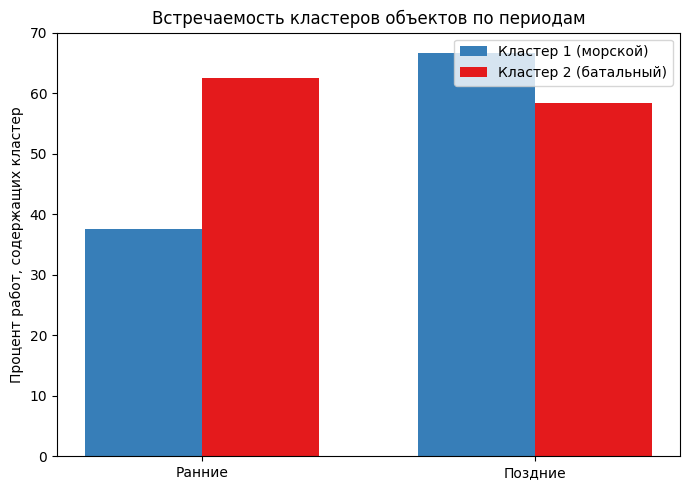

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

# Предполагается, что df уже загружен и содержит колонки 'group' и 'objects_parsed'
# (см. предыдущие ячейки)

# Определяем кластеры (из вашей дендрограммы)
cluster1 = ['люди', 'море', 'корабль', 'волны', 'облака', 'город']
cluster2 = ['деревья', 'лошади', 'человек', 'всадники', 'копья', 'лошадь', 'щиты', 'замок', 'река']

# Функция: встречается ли хотя бы один объект кластера в списке объектов работы
def has_cluster(objects_list, cluster):
    return any(obj in objects_list for obj in cluster)

# Добавляем булевы колонки
df['has_cluster1'] = df['objects_parsed'].apply(lambda x: has_cluster(x, cluster1))
df['has_cluster2'] = df['objects_parsed'].apply(lambda x: has_cluster(x, cluster2))

# Разделяем по периодам
early = df[df['group'] == 'early']
late = df[df['group'] == 'late']

# Процент работ, содержащих кластер
pct1_early = early['has_cluster1'].mean() * 100
pct1_late = late['has_cluster1'].mean() * 100
pct2_early = early['has_cluster2'].mean() * 100
pct2_late = late['has_cluster2'].mean() * 100

print(f"Кластер 1 (морской+город):")
print(f"  Ранние: {pct1_early:.1f}% работ")
print(f"  Поздние: {pct1_late:.1f}% работ")
print(f"Кластер 2 (батальный+пейзаж):")
print(f"  Ранние: {pct2_early:.1f}% работ")
print(f"  Поздние: {pct2_late:.1f}% работ")

# Статистические тесты (точный тест Фишера для 2x2 таблиц)
def test_cluster(df, col):
    early_has = early[col].sum()
    early_not = len(early) - early_has
    late_has = late[col].sum()
    late_not = len(late) - late_has
    table = [[early_has, early_not], [late_has, late_not]]
    odds, p = fisher_exact(table)
    return p

p1 = test_cluster(df, 'has_cluster1')
p2 = test_cluster(df, 'has_cluster2')
print(f"\nКластер 1: p = {p1:.5f} {'(значимо)' if p1 < 0.05 else '(не значимо)'}")
print(f"Кластер 2: p = {p2:.5f} {'(значимо)' if p2 < 0.05 else '(не значимо)'}")

# Визуализация
plt.figure(figsize=(7, 5))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [pct1_early, pct1_late], width, label='Кластер 1 (морской)', color='#377eb8')
plt.bar(x + width/2, [pct2_early, pct2_late], width, label='Кластер 2 (батальный)', color='#e41a1c')

plt.xticks(x, ['Ранние', 'Поздние'])
plt.ylabel('Процент работ, содержащих кластер')
plt.title('Встречаемость кластеров объектов по периодам')
plt.legend()
plt.tight_layout()
plt.show()